# Chapter 7: Bayesian Optimization with Gaussian Processes

Evaluating an agent harness across a full benchmark suite can cost tens of dollars and hours of wall-clock compute per configuration. Grid search over continuous parameters (`reasoning_tokens`, `context_limit`) is intractable. **Bayesian Optimization (BO)** builds a probabilistic **Gaussian Process (GP)** surrogate model of the expensive objective $f(\mathbf{x})$ and uses an **Acquisition Function** to select the most informative next configuration within **25 trials**.

---

## 1. Mathematical Formulations

### A. Gaussian Process Surrogate with Matérn $5/2$ Kernel
We model the unknown benchmark score $f(\mathbf{x}) \sim \mathcal{GP}(m(\mathbf{x}), k_{\nu=5/2}(\mathbf{x}, \mathbf{x}'))$ where the twice-differentiable **Matérn $5/2$ kernel** is:
$$k_{5/2}(r) = \sigma_f^2 \left(1 + \sqrt{5}r + \frac{5}{3}r^2\right) \exp\left(-\sqrt{5}r\right), \qquad r = \sqrt{\sum_{d=1}^D \frac{(x_d - x_d')^2}{\ell_d^2}}$$

Given $t$ noisy evaluations $\mathcal{D}_t = \{(\mathbf{x}_i, y_i)\}_{i=1}^t$, the GP provides closed-form posterior mean $\mu_t(\mathbf{x})$ and uncertainty $\sigma_t(\mathbf{x})$ at any candidate point $\mathbf{x}$.

### B. Acquisition Functions: Expected Improvement (EI) & GP-UCB
1. **Expected Improvement (EI)**:
   $$\text{EI}(\mathbf{x}) = \mathbb{E}\left[\max(0, f(\mathbf{x}) - y^+ - \xi)\right] = (\mu_t(\mathbf{x}) - y^+ - \xi)\Phi(Z) + \sigma_t(\mathbf{x})\phi(Z), \quad Z = \frac{\mu_t(\mathbf{x}) - y^+ - \xi}{\sigma_t(\mathbf{x})}$$
2. **Upper Confidence Bound (GP-UCB)**:
   $$\text{UCB}(\mathbf{x}) = \mu_t(\mathbf{x}) + \kappa \sigma_t(\mathbf{x})$$

## 🧠 Layman's Guide: Prospecting for Gold in the Fog with a Smart Uncertainty Radar

![Chapter 7: Bayesian Optimization with Gaussian Processes — Concept Illustration](../../figures/concepts/ch07_concept.jpg)

Imagine searching for the deepest oil reservoir across a vast mountain range covered in thick fog, where **drilling a single test well costs \$10,000** (just like running a full 500-task agent benchmark suite costs hours of GPU/API time):

- **Grid Search (The Brute-Force Way)**: Drilling a well every 100 yards on a $10 \times 10$ grid requires **100 wells (\$1,000,000)**—and 90% of those wells are wasted in flat, barren desert!
- **Bayesian Optimization (The Smart Radar)**:
  1. **The Surrogate Map (Gaussian Process)**: You drill 5 initial random wells. Between those 5 pins, the Gaussian Process draws a smooth contour map of the likely terrain (**Predicted Mean $\mu$**) AND a "Fog Thickness Map" (**Uncertainty $\sigma$**) that is zero right where you drilled and thickens in unexplored regions.
  2. **The Acquisition Compass (`Expected Improvement`)**: Where should you drill Well #6? You want a spot that either has a **high predicted score** (*Exploitation: drilling near your best discovery so far*) OR **huge uncertainty** (*Exploration: checking a big foggy corner that might hide a giant peak*). The Acquisition Function combines both into a single glowing beacon pointing to the exact most informative coordinate to test next!

Within just **25 trials** (instead of 100+ grid points), Bayesian Optimization locks onto the global peak.

---

### 🧗 Why This Matters for Agentic Hill-Climbing
> **Hill-Climbing Role**: *Stage 7 — Escaping Local Optima via Sample-Efficient Global Search (`CANDIDATE_SEARCH` Engine)*

Standard greedy **Agentic Hill-Climbing** suffers from a classic fatal flaw: **getting trapped on a local hill (local optimum)**.

- **What Breaks Without It (Stuck on a Foothill)**: Suppose your agent harness has a local performance bump around `reasoning_tokens=1,200, context_limit=25k` (72% pass rate) and a much taller global peak at `reasoning_tokens=2,850, context_limit=85k` (86% pass rate), separated by a dip. A greedy local hill-climber that only takes small steps uphill climbs onto the 72% foothill, sees the score drop in every immediate direction, and stops forever—missing the 86% global peak!
- **How It Supercharges the Hill-Climber**:
  1. **Memory of Uncertainty ($\sigma(\mathbf{x})$)**: Unlike greedy hill-climbing (which only remembers the current best point), a **Gaussian Process (`Matern 5/2`) Surrogate** remembers *every* configuration tested so far and knows exactly which regions of the parameter space are still unexplored (high $\sigma$).
  2. **Automated Exploration-Exploitation Switching**: When the local hill flattens out, the **Expected Improvement (EI)** and **GP-UCB** acquisition functions automatically shift weight to the exploration term $\sigma(\mathbf{x})\phi(Z)$, launching a targeted probe across the valley to discover the true global peak within **25 evaluations**.

---

### 📖 Plain-English Terminology & Jargon Buster

| Term / Symbol | Plain-English Meaning |
| :--- | :--- |
| **Black-Box Function** | A system (like a full agent benchmark run) where you can plug in configuration numbers and observe the final pass-rate score, but you don't have a simple math formula for what happens inside. |
| **Gaussian Process (GP) Surrogate** | A flexible statistical model that fits a smooth curve through the points you've tested so far, while also calculating a confidence band (uncertainty $\sigma$) at every untested point. |
| **Matérn 5/2 Kernel** | The 'smoothness rule' used by the Gaussian Process. Unlike overly smooth curves, Matérn 5/2 allows realistic bumps and sharp ridges common in ML hyperparameters. |
| **Exploration vs. Exploitation** | The fundamental dilemma: should you test right next to your current best setting (**Exploit**) or test a totally unknown region where uncertainty is high (**Explore**)? |
| **Acquisition Function (`Expected Improvement` / `GP-UCB`)** | A cheap formula that scores every possible untested setting based on both its predicted mean $\mu(x)$ and its uncertainty $\sigma(x)$, picking the highest scorer as the next trial. |

### 📚 Resources & Deeper Reading
- **Snoek, J., Larochelle, H., & Adams, R. P. (2012).** *Practical Bayesian Optimization of Machine Learning Algorithms.* NeurIPS 2012. [https://arxiv.org/abs/1206.2944](https://arxiv.org/abs/1206.2944) — The landmark paper that popularized GP Bayesian Optimization with Matérn 5/2 kernels for ML hyperparameter tuning.
- **Shahriari, B., Swersky, K., Wang, Z., Adams, R. P., & de Freitas, N. (2016).** *Taking the Human Out of the Loop: A Review of Bayesian Optimization.* Proceedings of the IEEE, 104(1), 148–175.
- **Rasmussen, C. E., & Williams, C. K. I. (2006).** *Gaussian Processes for Machine Learning.* MIT Press. [http://www.gaussianprocess.org/gpml/](http://www.gaussianprocess.org/gpml/)
- **Garnett, R. (2023).** *Bayesian Optimization.* Cambridge University Press. [https://bayesoptbook.com/](https://bayesoptbook.com/)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from agent_stats.ch07_bayesian_optimization import (
    evaluate_harness_config,
    expected_improvement,
    run_bayesian_optimization_loop,
    upper_confidence_bound,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

bo_res = run_bayesian_optimization_loop(
    n_init=5,
    n_total_trials=25,
    acquisition_type="EI",
    snapshot_iterations=(5, 12, 25),
    random_state=42,
)

print("=== BAYESIAN OPTIMIZATION CONVERGENCE SUMMARY (25 TRIALS) ===")
print(f"True Unknown Global Optimum : reasoning_tokens = {bo_res['true_optimum']['reasoning_tokens']:.0f}, "
      f"context_limit = {bo_res['true_optimum']['context_limit_k']:.1f}k -> Score = {bo_res['true_optimum']['true_score']:.4f}")
print(f"Discovered Optimum (Trial {bo_res['discovered_optimum']['trial']:2d}): reasoning_tokens = {bo_res['discovered_optimum']['reasoning_tokens']:.0f}, "
      f"context_limit = {bo_res['discovered_optimum']['context_limit_k']:.1f}k -> Score = {bo_res['discovered_optimum']['observed_score']:.4f}")

bo_res["history_df"].tail(10)

=== BAYESIAN OPTIMIZATION CONVERGENCE SUMMARY (25 TRIALS) ===
True Unknown Global Optimum : reasoning_tokens = 2787, context_limit = 38.1k -> Score = 0.9256
Discovered Optimum (Trial 13): reasoning_tokens = 2787, context_limit = 38.1k -> Score = 0.9378


,trial,phase,reasoning_tokens,context_limit_k,observed_score,best_score_so_far
15,16,BO (EI),256.000000,4.000000,0.414610,0.937848
16,17,BO (EI),2699.636364,38.090909,0.927724,0.937848
17,18,BO (EI),4096.000000,4.000000,0.413942,0.937848
18,19,BO (EI),1652.363636,4.000000,0.452189,0.937848
19,20,BO (EI),2874.181818,39.454545,0.924813,0.937848
20,21,BO (EI),4096.000000,64.000000,0.478277,0.937848
21,22,BO (EI),2786.909091,36.727273,0.914458,0.937848
22,23,BO (EI),2699.636364,39.454545,0.916964,0.937848
23,24,BO (EI),2786.909091,39.454545,0.917177,0.937848
24,25,BO (EI),2874.181818,38.090909,0.926950,0.937848


## 2. Side-by-Side Visualizations Across Iterations: GP Predicted Mean Surface vs. Acquisition Surface

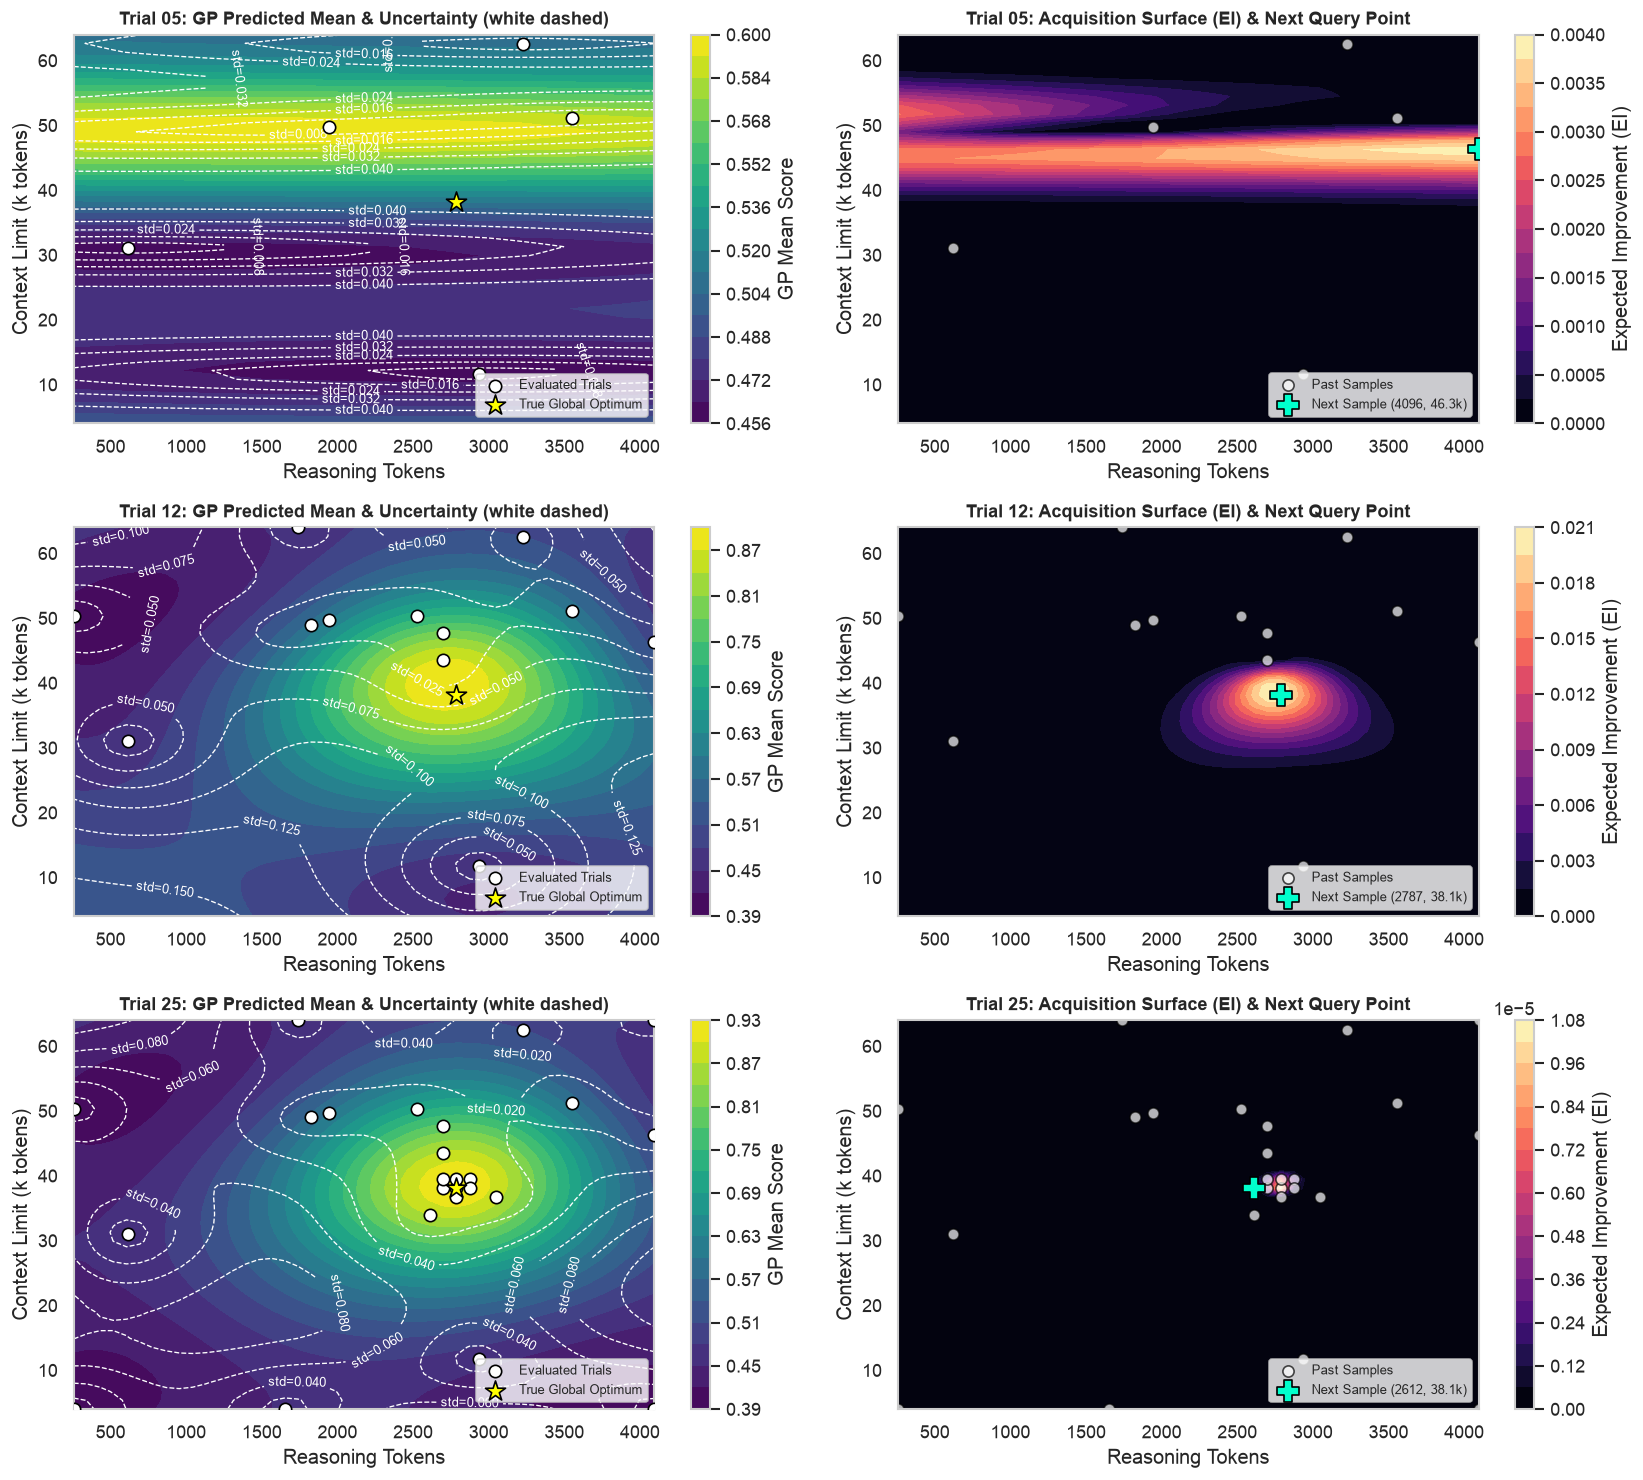

In [2]:
rr = bo_res["r_grid"]
cc = bo_res["c_grid"]
snap_steps = [5, 12, 25]

fig, axes = plt.subplots(len(snap_steps), 2, figsize=(14, 12.5))

for row_idx, step in enumerate(snap_steps):
    snap = bo_res["snapshots"][step]
    x_obs = snap["x_observed"]
    next_pt = snap["next_point"]

    # Left column: GP Posterior Mean Surface + Uncertainty Contour + Sampled Points
    ax_mean = axes[row_idx, 0]
    c1 = ax_mean.contourf(rr, cc, snap["mu_surface"], levels=18, cmap="viridis")
    cs_std = ax_mean.contour(rr, cc, snap["std_surface"], levels=6, colors="white", linewidths=0.8, linestyles="--")
    ax_mean.clabel(cs_std, inline=True, fontsize=7.5, fmt="std=%.3f")
    ax_mean.scatter(x_obs[:, 0], x_obs[:, 1], c="white", edgecolor="black", s=55, zorder=4, label="Evaluated Trials")
    ax_mean.scatter([bo_res["true_optimum"]["reasoning_tokens"]], [bo_res["true_optimum"]["context_limit_k"]],
                    c="yellow", edgecolor="black", marker="*", s=160, zorder=5, label="True Global Optimum")
    plt.colorbar(c1, ax=ax_mean, label="GP Mean Score")
    ax_mean.set_title(f"Trial {step:02d}: GP Predicted Mean & Uncertainty (white dashed)", fontsize=11, fontweight="bold")
    ax_mean.set_xlabel("Reasoning Tokens")
    ax_mean.set_ylabel("Context Limit (k tokens)")
    ax_mean.legend(loc="lower right", fontsize=8)

    # Right column: Expected Improvement (EI) Acquisition Surface + Next Chosen Coordinate
    ax_acq = axes[row_idx, 1]
    c2 = ax_acq.contourf(rr, cc, snap["acq_surface"], levels=18, cmap="magma")
    ax_acq.scatter(x_obs[:, 0], x_obs[:, 1], c="white", edgecolor="black", s=45, alpha=0.7, label="Past Samples")
    ax_acq.scatter([next_pt[0]], [next_pt[1]], c="#00ffcc", edgecolor="black", marker="P", s=160, zorder=6,
                   label=f"Next Sample ({next_pt[0]:.0f}, {next_pt[1]:.1f}k)")
    plt.colorbar(c2, ax=ax_acq, label="Expected Improvement (EI)")
    ax_acq.set_title(f"Trial {step:02d}: Acquisition Surface (EI) & Next Query Point", fontsize=11, fontweight="bold")
    ax_acq.set_xlabel("Reasoning Tokens")
    ax_acq.set_ylabel("Context Limit (k tokens)")
    ax_acq.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("figures/ch07_bayesian_optimization_surfaces.png", dpi=150, bbox_inches="tight")
plt.show()